<a href="https://colab.research.google.com/github/koushik1904/ML_assignments/blob/main/ML_assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [2]:
df = pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

In [4]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [5]:
X = np.c_[np.ones(X.shape[0]), X]

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [7]:
def train(X, y, lr, epochs):
    w = np.zeros(X.shape[1])
    m = len(y)
    for _ in range(epochs):
        z = np.dot(X, w)
        h = sigmoid(z)
        grad = np.dot(X.T, (h - y)) / m
        w -= lr * grad
    return w

In [8]:
def predict(X, w):
    return (sigmoid(np.dot(X, w)) >= 0.5).astype(int)

In [9]:
for lr in [0.01, 0.001]:
    w = train(X, y, lr, 1000)
    y_pred = predict(X, w)

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)

    print("Learning Rate:", lr)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print()

Learning Rate: 0.01
Accuracy: 0.76953125
Precision: 0.7116279069767442
Recall: 0.5708955223880597

Learning Rate: 0.001
Accuracy: 0.7526041666666666
Precision: 0.648854961832061
Recall: 0.6343283582089553



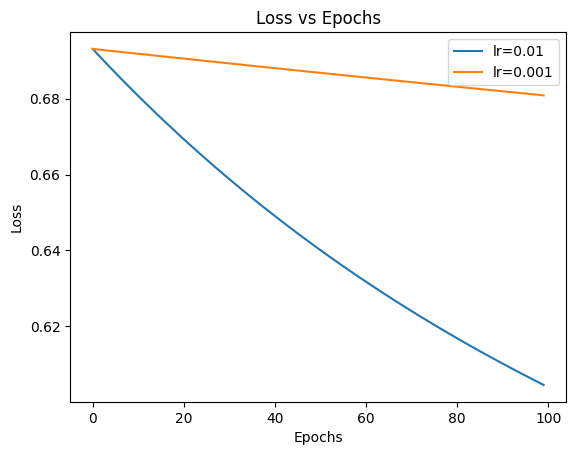

In [10]:
import matplotlib.pyplot as plt

def compute_loss(y, h):
    m = len(y)
    return - (1/m) * np.sum(y*np.log(h + 1e-9) + (1-y)*np.log(1-h + 1e-9))

def train_with_loss(X, y, lr, epochs):
    w = np.zeros(X.shape[1])
    losses = []
    m = len(y)

    for _ in range(epochs):
        z = np.dot(X, w)
        h = sigmoid(z)

        loss = compute_loss(y, h)
        losses.append(loss)

        grad = np.dot(X.T, (h - y)) / m
        w -= lr * grad

    return losses

loss1 = train_with_loss(X, y, 0.01, 100)
loss2 = train_with_loss(X, y, 0.001, 100)

plt.figure()
plt.plot(loss1, label="lr=0.01")
plt.plot(loss2, label="lr=0.001")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.show()